In [1]:
import time
import random
import statistics
import matplotlib.pyplot as plt


def find_median(A, B):

    # Always binary-search the smaller array
    if len(A) > len(B):
        A, B = B, A

    m = len(A)
    n = len(B)

    low = 0
    high = m

    while low <= high:

        partition_A = (low + high) // 2
        partition_B = (m + n + 1) // 2 - partition_A

        # Elements just to the left/right of partitions
        if partition_A == 0:
            max_left_A = float('-inf')
        else:
            max_left_A = A[partition_A - 1]

        if partition_A == m:
            min_right_A = float('inf')
        else:
            min_right_A = A[partition_A]

        if partition_B == 0:
            max_left_B = float('-inf')
        else:
            max_left_B = B[partition_B - 1]

        if partition_B == n:
            min_right_B = float('inf')
        else:
            min_right_B = B[partition_B]

        # Correct partition
        if max_left_A <= min_right_B and max_left_B <= min_right_A:

            # Even total number of elements
            if (m + n) % 2 == 0:

                return (
                    max(max_left_A, max_left_B)
                    + min(min_right_A, min_right_B)
                ) / 2

            # Odd total number of elements
            else:

                return max(max_left_A, max_left_B)

        # Partition A is too far right
        elif max_left_A > min_right_B:

            high = partition_A - 1

        # Partition A is too far left
        else:

            low = partition_A + 1

    return None

# Generate fixed sorted arrays

def generate_sorted_array(n):

    arr = [random.randint(1, 1000000) for _ in range(n)]
    arr.sort()

    return arr



sizes = list(range(1000, 100001, 5000))

median_times = []

runs = 20
repetitions = 1000



for size in sizes:

    # Generate the arrays ONCE
    A = generate_sorted_array(size)
    B = generate_sorted_array(size)

    measurements = []

    for _ in range(runs):

        start = time.perf_counter_ns()

        for _ in range(repetitions):
            find_median(A, B)

        end = time.perf_counter_ns()

        # Average time for ONE execution
        elapsed = (end - start) / repetitions

        measurements.append(elapsed)

    # Median of the measurements
    median_times.append(statistics.median(measurements))

    print(f"Input size {size} completed")

Input size 1000 completed
Input size 6000 completed
Input size 11000 completed
Input size 16000 completed
Input size 21000 completed
Input size 26000 completed
Input size 31000 completed
Input size 36000 completed
Input size 41000 completed
Input size 46000 completed
Input size 51000 completed
Input size 56000 completed
Input size 61000 completed
Input size 66000 completed
Input size 71000 completed
Input size 76000 completed
Input size 81000 completed
Input size 86000 completed
Input size 91000 completed
Input size 96000 completed


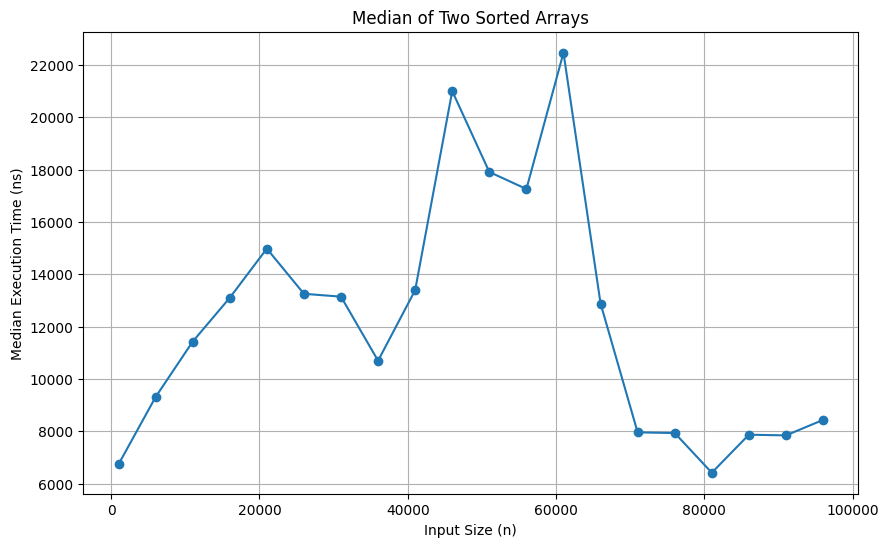

In [2]:
plt.figure(figsize=(10, 6))

plt.plot(
    sizes,
    median_times,
    marker='o'
)

plt.title("Median of Two Sorted Arrays")
plt.xlabel("Input Size (n)")
plt.ylabel("Median Execution Time (ns)")
plt.grid(True)

plt.show()